In [1]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-1 * z))

In [2]:
print(sigmoid(0))
print(sigmoid(5))
print(sigmoid(-5))

0.5
0.9933071490757153
0.0066928509242848554


In [3]:
def predict_proba(X, w, b):
    z = np.dot(X,w) + b
    return sigmoid(z)

In [4]:
X_test = np.array([
    [1.0, 2.0],
    [2.0, 1.0]
])

w_test = np.array([0.5, -0.5])
b_test = 0.0

print(predict_proba(X_test, w_test, b_test))

[0.37754067 0.62245933]


In [10]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    f = predict_proba(X, w, b)
    total_cost = (-1 * y * np.log(f) - (1 - y) * np.log(1- f))
    return np.sum(total_cost) / m

In [11]:
y_test = np.array([0, 1])

print(compute_cost(X_test, y_test, w_test, b_test))

0.47407698418010663


In [13]:
def compute_gradient(X, y, w, b):
    m = X.shape[0]

    f = predict_proba(X, w, b)
    errors = f - y
    dj_dw = (X.T @ errors) / m
    dj_db = np.sum(errors) / m

    return dj_dw, dj_db

In [14]:
dj_dw, dj_db = compute_gradient(
    X_test, y_test, w_test, b_test
)

print("dj_dw:", dj_dw)
print("dj_db:", dj_db)

dj_dw: [-0.18877033  0.18877033]
dj_db: 0.0


In [15]:
print(X_test)
print(y_test)
print(X_test.shape)

[[1. 2.]
 [2. 1.]]
[0 1]
(2, 2)


In [16]:
X_test = np.array([
    [1.0, 2.0],
    [2.0, 1.0],
    [3.0, 1.5]
])

y_test = np.array([0, 1, 1])

In [17]:
dj_dw, dj_db = compute_gradient(
    X_test, y_test, w_test, b_test
)

print("dj_dw:", dj_dw)
print("dj_db:", dj_db)

dj_dw: [-0.44666819 -0.03456376]
dj_db: -0.10694043360820234


In [18]:
def gradient_descent(X, y, w, b, alpha, iterations):
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X,y,w,b)
        w -= (alpha * dj_dw)
        b -= (alpha * dj_db)

    return w, b

In [19]:
X = np.array([
    [0.5],
    [1.0],
    [1.5],
    [2.0],
    [2.5],
    [3.0],
    [3.5],
    [4.0]
])

y = np.array([0,0,0,0,1,1,1,1])

w = np.zeros(X.shape[1])
b = 0.0

w, b = gradient_descent(
    X, y, w, b,
    alpha=0.1,
    iterations=1000
)

print("w:", w)
print("b:", b)
print("cost:", compute_cost(X, y, w, b))

w: [2.49930088]
b: -5.372002132408177
cost: 0.15988835788253064


In [20]:
boundary = -b / w[0]

print("decision boundary:", boundary)
print("probabilities:", predict_proba(X, w, b))

decision boundary: 2.1494019292343336
probabilities: [0.0159479  0.05351965 0.16478456 0.40771963 0.70604454 0.8933952
 0.96693164 0.99029346]


In [21]:
predictions = (predict_proba(X, w, b) >= 0.5).astype(int)

print("predictions:", predictions)
print("true labels:", y)

predictions: [0 0 0 0 1 1 1 1]
true labels: [0 0 0 0 1 1 1 1]


In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=1e6, max_iter=10000)
model.fit(X, y)

w_sk = model.coef_[0, 0]
b_sk = model.intercept_[0]
boundary_sk = -b_sk / w_sk

print("Our boundary:", boundary)
print("Sklearn boundary:", boundary_sk)

print("Our predictions:", predictions)
print("Sklearn predictions:", model.predict(X))

print("Sklearn probabilities:", model.predict_proba(X)[:, 1])

Our boundary: 2.1494019292343336
Sklearn boundary: 2.258832576219903
Our predictions: [0 0 0 0 1 1 1 1]
Sklearn predictions: [0 0 0 0 1 1 1 1]
Sklearn probabilities: [8.31981435e-25 5.82815469e-18 4.08270974e-11 2.85918166e-04
 9.99501116e-01 1.00000000e+00 1.00000000e+00 1.00000000e+00]


In [23]:
def gradient_descent(X, y, w, b, alpha, iterations):
    cost_history = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost_history.append(compute_cost(X, y, w, b))

    return w, b, cost_history

In [24]:
w = np.zeros(X.shape[1])
b = 0.0

w, b, cost_history = gradient_descent(
    X, y, w, b,
    alpha=0.1,
    iterations=1000
)

print("Initial cost:", cost_history[0])
print("Final cost:", cost_history[-1])

Initial cost: 0.6701371419488146
Final cost: 0.15988835788253064


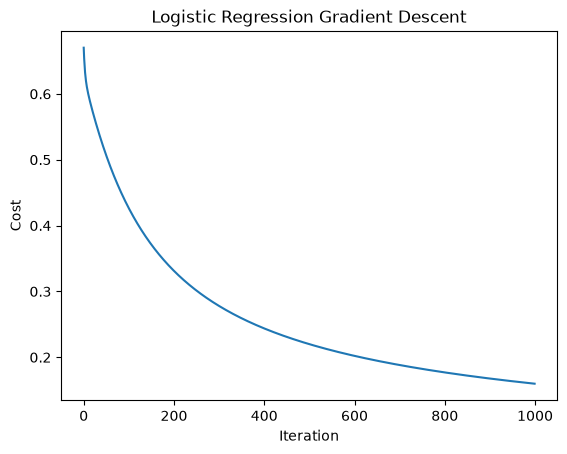

In [25]:
import matplotlib.pyplot as plt

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Logistic Regression Gradient Descent")
plt.show()

## Conclusion

In logistic regression, the prediction is

$$
f_{w,b}(x) = \sigma(w^Tx + b)
$$

and the binary cross-entropy cost is minimized using gradient descent.

The gradient update has the same mathematical form as linear regression, but the prediction function is different because logistic regression uses the sigmoid function.

In the toy experiment, gradient descent reduced the cost from about `0.67` to `0.16`, and the final classifier correctly separated all training examples.